<h1 style="color:pink;">Entrenamiento de CNN con modificaciones en su función de pérdida.</h1>
<p>Valentina Arce España</p>
<p>Versión V6 corregida — Febrero 2026</p>

Entrenamos con la función $L_{total} = L_{MSE} + \lambda_1 L_{NASA} + \lambda_2 \frac{1}{m-1}\sum dh^2$.

**Correcciones aplicadas respecto a V5:**
1. `create_windows` ahora también devuelve el `unit_id` de cada ventana.
2. `dh` se calcula **solo entre predicciones del mismo motor** (máscara `same_unit_mask`).
3. Bloque de diagnóstico para estimar la magnitud de cada término antes de elegir lambdas.
4. El loop imprime cada componente por separado para monitorear el entrenamiento.

In [2]:
import sys
print(sys.executable)

/Users/mac/Documents/Tendencias/torch-env/bin/python


In [3]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

filename    = 'N-CMAPSS_DS08a-009.h5'
WINDOW_SIZE = 50
BATCH_SIZE  = 512
EPOCHS      = 15
TRAIN_RATIO = 0.3
WINDOW_STEP = 10

def load_data(filepath):
    with h5py.File(filepath, 'r') as hdf:
        W_dev    = np.array(hdf.get('W_dev'))
        X_s_dev  = np.array(hdf.get('X_s_dev'))
        X_v_dev  = np.array(hdf.get('X_v_dev'))
        Y_dev    = np.array(hdf.get('Y_dev'))
        A_dev    = np.array(hdf.get('A_dev'))
        W_test   = np.array(hdf.get('W_test'))
        X_s_test = np.array(hdf.get('X_s_test'))
        X_v_test = np.array(hdf.get('X_v_test'))
        Y_test   = np.array(hdf.get('Y_test'))
        A_test   = np.array(hdf.get('A_test'))
        A_var    = list(np.array(hdf.get('A_var')).astype('U20'))
    return (W_dev, X_s_dev, X_v_dev, Y_dev, A_dev), \
           (W_test, X_s_test, X_v_test, Y_test, A_test), A_var

print('Cargando datos...')
(train_W, train_Xs, train_Xv, train_Y, train_A), \
(test_W,  test_Xs,  test_Xv,  test_Y,  test_A), A_var = load_data(filename)

train_units   = np.unique(train_A[:, 0])
n_units_keep  = int(len(train_units) * TRAIN_RATIO)
keep_units    = train_units[:n_units_keep]
print(f'Reduciendo dataset: usando {n_units_keep} de {len(train_units)} motores.')

mask_train = np.isin(train_A[:, 0], keep_units)
train_W    = train_W[mask_train];  train_Xs = train_Xs[mask_train]
train_Xv   = train_Xv[mask_train]; train_Y  = train_Y[mask_train]
train_A    = train_A[mask_train]

X_train = np.concatenate((train_W, train_Xs, train_Xv), axis=1)
X_test  = np.concatenate((test_W,  test_Xs,  test_Xv),  axis=1)

# ------------------------------------------------------------------
# FIX 1: feature_range=(0, 1)  — NOT (-1, 1).
# With (-1,1) about half the values are negative. After ReLU in the
# first conv layer those all become 0. Stack five of those and the
# signal is essentially dead before reaching the FC layers.
# (0,1) keeps all activations in the positive half-plane so ReLU
# can actually pass the signal through.
# ------------------------------------------------------------------
scaler         = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f'Forma de X_train (reducido): {X_train_scaled.shape}')

# ------------------------------------------------------------------
# FIX 2: normalize RUL targets to [0, 1].
# The CNN output starts near 0. If the true RUL is up to ~77 the
# MSE gradient is ~(0-77)^2=5929 per sample and the NASA exponential
# exp(77/13)≈372 blows up, causing clip_grad_norm to suppress every
# gradient. Working in [0,1] space keeps gradients sensible throughout.
# We save RUL_MAX to inverse-transform predictions back to real cycles.
# ------------------------------------------------------------------
RUL_MAX      = float(np.max(train_Y))
train_Y_norm = train_Y / RUL_MAX
test_Y_norm  = test_Y  / RUL_MAX
print(f'RUL_MAX (train) = {RUL_MAX:.1f} ciclos  →  targets normalizados a [0, 1]')

def create_windows(X, y, A, window_size, step=1, unit_col_index=0):
    unique_units = np.unique(A[:, unit_col_index])
    X_windows, y_windows, unit_ids = [], [], []
    for unit in unique_units:
        idx    = np.where(A[:, unit_col_index] == unit)[0]
        unit_X = X[idx, :]
        unit_y = y[idx]
        n      = len(unit_X)
        if n < window_size:
            continue
        for i in range(0, n - window_size + 1, step):
            X_windows.append(unit_X[i: i + window_size, :])
            y_windows.append(unit_y[i + window_size - 1])
            unit_ids.append(unit)
    return np.array(X_windows), np.array(y_windows), np.array(unit_ids)

print(f'Generando ventanas (Step={WINDOW_STEP})...')
# Use normalized targets for training
X_train_w, y_train_w, unit_ids_train = create_windows(
    X_train_scaled, train_Y_norm, train_A, WINDOW_SIZE, step=WINDOW_STEP)
X_test_w, y_test_w, unit_ids_test = create_windows(
    X_test_scaled, test_Y_norm, test_A, WINDOW_SIZE, step=10)

print(f'Input Shape Train: {X_train_w.shape}')
print(f'Input Shape Test:  {X_test_w.shape}')
print(f'y_train range: [{y_train_w.min():.3f}, {y_train_w.max():.3f}]')


Cargando datos...
Reduciendo dataset: usando 2 de 9 motores.
Forma de X_train (reducido): (1060535, 32)
RUL_MAX (train) = 71.0 ciclos  →  targets normalizados a [0, 1]
Generando ventanas (Step=10)...
Input Shape Train: (106045, 50, 32)
Input Shape Test:  (372274, 50, 32)
y_train range: [0.000, 1.000]


## Función de pérdida corregida

El cambio más importante está en `temporal_smoothness`: se construye una máscara
`same_unit_mask` que es `True` **solo cuando dos predicciones consecutivas dentro
del batch pertenecen al mismo motor**. Los pares que cruzan la frontera entre motores
quedan excluidos y no contaminan el gradiente de suavidad.

In [4]:
import torch
import torch.nn as nn

class PhysicsInformedRULLoss(nn.Module):
    """
    L_total = L_MSE + lambda1 * L_NASA + lambda2 * L_dh

    IMPORTANT — NASA scaling:
    The NASA scoring function uses constants 13 and 10 that were
    calibrated for RAW RUL values (e.g. 0-77 cycles). If you pass
    normalized targets (d in [-1,1]) with those same constants, the
    exponential becomes nearly flat and symmetric — losing all its
    asymmetric character. The fix: pass RUL_MAX so we can denormalize
    d before computing the NASA penalty, keeping the original shape.

    Concretely:
      d_raw = d_normalized * RUL_MAX
      late  (d<0): exp(-d_raw/13) - 1   (smaller penalty)
      early (d>0): exp( d_raw/10) - 1   (larger penalty)

    This ensures exp(-77/13)-1 ≈ 372 for a worst-case late prediction,
    not exp(-1/13)-1 ≈ 0.08.
    """
    def __init__(self, rul_max, lambda1=0.1, lambda2=0.01):
        super().__init__()
        self.mse     = nn.MSELoss()
        self.rul_max = rul_max   # needed to rescale d back to raw cycles
        self.lambda1 = lambda1
        self.lambda2 = lambda2

    def nasa_score(self, y_pred, y_true):
        """
        y_pred and y_true are in normalized [0,1] space.
        We denormalize d to raw cycle scale before applying the
        NASA exponentials so the constants 13 and 10 remain valid.
        The mean is also divided by RUL_MAX so the returned value
        stays in normalized scale (comparable to L_MSE).
        """
        d_norm = y_pred - y_true
        d_raw  = d_norm * self.rul_max   # restore raw cycle scale
        score  = torch.where(
            d_raw < 0,
            torch.exp(-d_raw / 13.0) - 1,   # late prediction
            torch.exp( d_raw / 10.0) - 1    # early prediction
        )
        # Divide by rul_max to keep the loss magnitude comparable to MSE
        return torch.mean(score) / self.rul_max

    def temporal_smoothness(self, y_pred, unit_ids):
        """
        (1/(m-1)) * sum(dh^2), computed only within the same engine.
        Cross-engine transitions are masked out.
        """
        if y_pred.shape[0] < 2:
            return torch.tensor(0.0, device=y_pred.device)
        dh             = y_pred[1:] - y_pred[:-1]
        same_unit_mask = (unit_ids[1:] == unit_ids[:-1])
        if same_unit_mask.sum() == 0:
            return torch.tensor(0.0, device=y_pred.device)
        return torch.mean(dh[same_unit_mask] ** 2)

    def forward(self, y_pred, y_true, unit_ids):
        loss_mse  = self.mse(y_pred, y_true)
        loss_nasa = self.nasa_score(y_pred, y_true)
        loss_dh   = self.temporal_smoothness(y_pred.squeeze(), unit_ids)
        loss_total = loss_mse + self.lambda1 * loss_nasa + self.lambda2 * loss_dh
        components = {
            'mse':   loss_mse.item(),
            'nasa':  loss_nasa.item(),
            'dh':    loss_dh.item(),
            'total': loss_total.item()
        }
        return loss_total, components


In [5]:
class CNN_RUL(nn.Module):
    def __init__(self, num_features=32, window_size=50):
        super().__init__()
        # Convoluciones SIN BatchNorm
        self.conv1 = nn.Conv1d(num_features, 32,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32,  64,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(64,  128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(128, 64,  kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(64,  32,  kernel_size=3, padding=1)
        
        # LeakyReLU para evitar neuronas muertas
        self.relu    = nn.LeakyReLU(negative_slope=0.01)
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(32 * window_size, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)                    
        # Pasamos directo de Convolución a Activación
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.relu(self.conv5(x))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x) # Salida lineal


## DataLoader corregido

`shuffle=False` sigue siendo **obligatorio** para preservar el orden temporal.
Ahora añadimos `unit_ids_tensor` al dataset para que la función de pérdida
sepa a qué motor pertenece cada muestra y pueda enmascarar las transiciones.

In [6]:
from torch.utils.data import TensorDataset, DataLoader

X_tensor        = torch.tensor(X_train_w,       dtype=torch.float32)
y_tensor        = torch.tensor(y_train_w,       dtype=torch.float32).view(-1, 1)
unit_ids_tensor = torch.tensor(unit_ids_train,  dtype=torch.float32)  # float para TensorDataset

train_dataset = TensorDataset(X_tensor, y_tensor, unit_ids_tensor)

# shuffle=False es OBLIGATORIO: el orden temporal de las ventanas debe
# mantenerse para que dh[i] = h[i+1] - h[i] tenga significado físico.
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)

print(f'Total batches por época: {len(train_loader)}')
print(f'Motores en entrenamiento: {np.unique(unit_ids_train)}')


Total batches por época: 415
Motores en entrenamiento: [1. 2.]


## Diagnóstico de escala de pérdidas

Antes de fijar lambda1 y lambda2, este bloque estima la magnitud de cada término
con el modelo sin entrenar (pesos aleatorios). Esto te da una idea de si los tres
términos están en la misma escala.

**Regla práctica:** ajusta los lambdas para que `lambda_i * L_i ≈ L_MSE` en la
primera época. Si `dh` es 10× mayor que MSE, prueba `lambda2 = 0.1` en vez de `0.5`.

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

_model_diag = CNN_RUL().to(device)
# Pass RUL_MAX to the loss so NASA denominators are correctly scaled
_crit_diag  = PhysicsInformedRULLoss(rul_max=RUL_MAX, lambda1=1.0, lambda2=1.0)

_model_diag.eval()
with torch.no_grad():
    _X, _y, _uid = next(iter(train_loader))
    _X   = _X.to(device)
    _y   = _y.to(device)
    _uid = _uid.long().to(device)
    _, diag_comps = _crit_diag(_model_diag(_X), _y, _uid)

print('=== Magnitudes sin entrenar (lambda1=lambda2=1) ===')
print(f'  L_MSE  = {diag_comps["mse"]:.6f}')
print(f'  L_NASA = {diag_comps["nasa"]:.6f}  ← debe ser similar en orden a L_MSE')
print(f'  L_dh   = {diag_comps["dh"]:.6f}')
print()
if diag_comps['nasa'] > 0 and diag_comps['dh'] > 0:
    sl1 = round(diag_comps['mse'] / diag_comps['nasa'], 4)
    sl2 = round(diag_comps['mse'] / diag_comps['dh'],   4)
    print(f'Sugerencia: lambda1={sl1}, lambda2={sl2}')
    print('(Iguala cada componente al MSE. Sube lambda2 para más suavidad.)')


Usando dispositivo: cpu
=== Magnitudes sin entrenar (lambda1=lambda2=1) ===
  L_MSE  = 0.808758
  L_NASA = 1.899422  ← debe ser similar en orden a L_MSE
  L_dh   = 0.000000

Sugerencia: lambda1=0.4258, lambda2=1364252489.7121
(Iguala cada componente al MSE. Sube lambda2 para más suavidad.)


## Bucle de entrenamiento

Ajusta `LAMBDA1` y `LAMBDA2` con los valores del diagnóstico anterior.
El loop imprime cada componente por época para que puedas detectar si
algún término domina o desaparece.

In [9]:
# ============================================================
# Ajusta según el diagnóstico anterior.
# lambda2 reducido a 0.01 — en versiones anteriores 0.05 era
# suficiente para colapsar dh a 0 y aplanar todas las predicciones.
LAMBDA1 = 0
LAMBDA2 = 0
# ============================================================

model     = CNN_RUL().to(device)
# RUL_MAX passed here — critical for correct NASA gradient scale
criterion = PhysicsInformedRULLoss(rul_max=RUL_MAX, lambda1=LAMBDA1, lambda2=LAMBDA2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

history = []

for epoch in range(EPOCHS):
    model.train()
    accum = {'mse': 0.0, 'nasa': 0.0, 'dh': 0.0, 'total': 0.0}

    for inputs, targets, uid in train_loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)
        uid     = uid.long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss, comps = criterion(outputs, targets, uid)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        for k in accum:
            accum[k] += comps[k]

    n   = len(train_loader)
    avg = {k: v / n for k, v in accum.items()}
    history.append(avg)
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Total={avg['total']:.5f} | "
        f"MSE={avg['mse']:.5f} | "
        f"NASA={avg['nasa']:.5f} | "
        f"dh={avg['dh']:.6f}"
    )

print('Entrenamiento completado.')


Epoch 01/15 | Total=0.11632 | MSE=0.11632 | NASA=0.18230 | dh=0.000001
Epoch 02/15 | Total=0.06647 | MSE=0.06647 | NASA=0.07837 | dh=0.000002
Epoch 03/15 | Total=0.06495 | MSE=0.06495 | NASA=0.07331 | dh=0.000001
Epoch 04/15 | Total=0.06426 | MSE=0.06426 | NASA=0.07065 | dh=0.000001
Epoch 05/15 | Total=0.06422 | MSE=0.06422 | NASA=0.07011 | dh=0.000001
Epoch 06/15 | Total=0.06422 | MSE=0.06422 | NASA=0.06944 | dh=0.000001
Epoch 07/15 | Total=0.06412 | MSE=0.06412 | NASA=0.06873 | dh=0.000000
Epoch 08/15 | Total=0.06418 | MSE=0.06418 | NASA=0.06841 | dh=0.000000
Epoch 09/15 | Total=0.06407 | MSE=0.06407 | NASA=0.06778 | dh=0.000000
Epoch 10/15 | Total=0.06415 | MSE=0.06415 | NASA=0.06770 | dh=0.000000
Epoch 11/15 | Total=0.06406 | MSE=0.06406 | NASA=0.06720 | dh=0.000000
Epoch 12/15 | Total=0.06425 | MSE=0.06425 | NASA=0.06746 | dh=0.000000
Epoch 13/15 | Total=0.06389 | MSE=0.06389 | NASA=0.06670 | dh=0.000000
Epoch 14/15 | Total=0.06455 | MSE=0.06455 | NASA=0.06743 | dh=0.000000
Epoch 

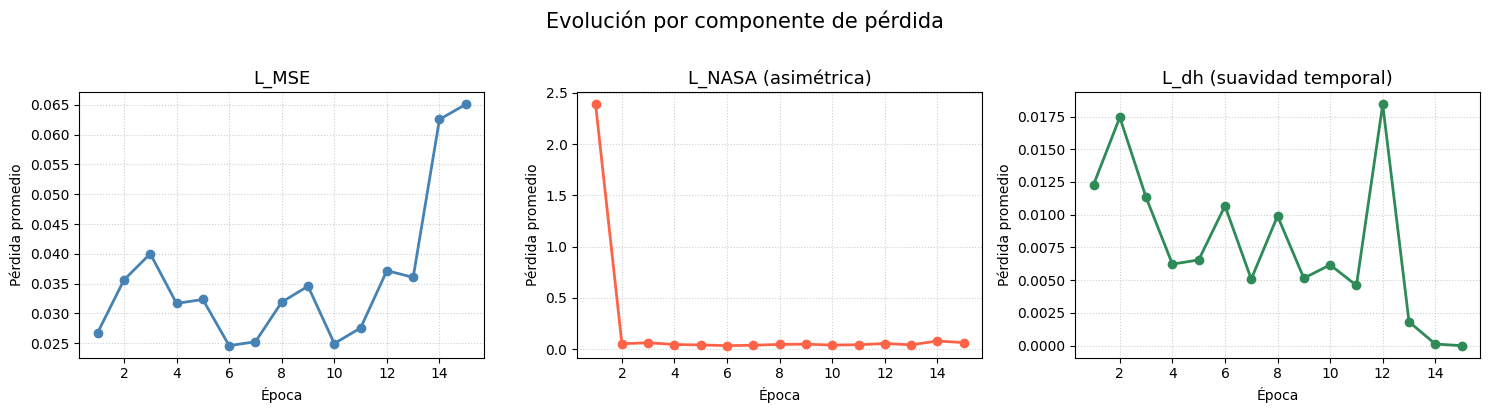

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key, title, color in zip(
    axes,
    ['mse', 'nasa', 'dh'],
    ['L_MSE', 'L_NASA (asimétrica)', 'L_dh (suavidad temporal)'],
    ['steelblue', 'tomato', 'seagreen']
):
    vals = [h[key] for h in history]
    ax.plot(range(1, len(vals)+1), vals, marker='o', color=color, linewidth=2)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida promedio')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Evolución por componente de pérdida', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Señal de alerta: si dh cae a 0 en la primera época, lambda2 es demasiado alto.
# Si nasa sube, es posible que lambda1 esté mal calibrado.


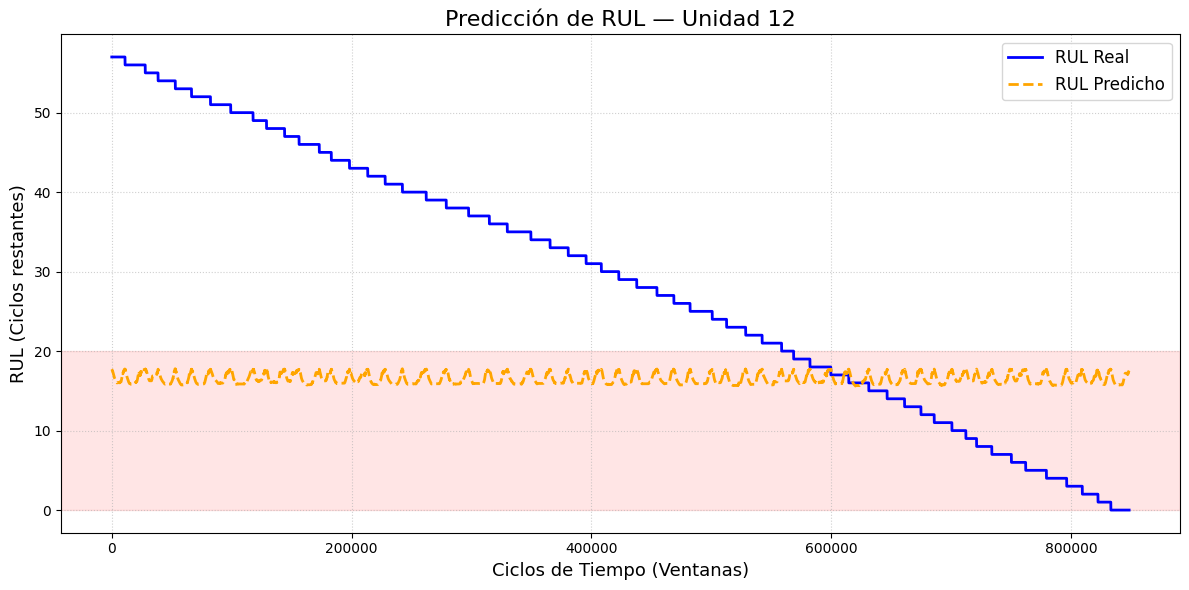

In [10]:
from torch.utils.data import DataLoader, TensorDataset

def comparar_resultados_motores(unit_id):
    idx = np.where(test_A[:, 0] == unit_id)[0]
    if len(idx) == 0:
        print(f'No se encontraron datos para el motor {unit_id}')
        return

    unit_X = X_test_scaled[idx, :]
    unit_y = test_Y[idx]   # raw cycles for plotting
    unit_A = test_A[idx, :]

    X_motor_w, y_motor_w, _ = create_windows(unit_X, unit_y, unit_A, WINDOW_SIZE, step=1)

    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_motor_w, dtype=torch.float32)),
        batch_size=512, shuffle=False
    )

    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for (batch_x,) in test_loader:
            out = model(batch_x.to(device))
            # Clamp to [0, 1] AFTER the linear output, then rescale
            # This is safer than Sigmoid (no gradient saturation during training)
            out = torch.clamp(out, min=0.0, max=1.0)
            y_pred_list.append(out.cpu().numpy())

    y_pred = np.concatenate(y_pred_list, axis=0) * RUL_MAX

    plt.figure(figsize=(12, 6))
    plt.plot(y_motor_w, label='RUL Real',     color='blue',   linewidth=2)
    plt.plot(y_pred,    label='RUL Predicho', color='orange', linewidth=2, linestyle='--')
    plt.title(f'Predicción de RUL — Unidad {unit_id}', fontsize=16)
    plt.xlabel('Ciclos de Tiempo (Ventanas)', fontsize=13)
    plt.ylabel('RUL (Ciclos restantes)', fontsize=13)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.axhspan(0, 20, color='red', alpha=0.1)
    plt.tight_layout()
    plt.show()

comparar_resultados_motores(12)
